# 04 — PyCAP Parameter Perturbation

**Purpose:** Run the first deterministic uncertainty/sensitivity experiments with the Little Plover River PyCAP analytical model.

This notebook builds directly from:

```text
02_pycap_baseline_run_check.ipynb
03_pycap_input_inventory.ipynb
```

The goal is to test simple parameter perturbations around the verified baseline model:

```text
baseline
T × 0.90
T × 1.10
S × 0.90
S × 1.10
Q × 0.90
Q × 1.10
```

where:

- `T` = transmissivity, stored globally in `project_properties`
- `S` = storage, stored globally in `project_properties`
- `Q` = well pumping rate, stored separately for each well

## Big conceptual idea

This is not a full Monte Carlo uncertainty analysis yet.

This is a **one-at-a-time perturbation test**:

> Change one input, rerun PyCAP, and compare the output to baseline.

This is the simplest way to learn which model inputs matter before building a larger uncertainty workflow.


## 1. Imports and project-root setup

In [1]:
from pathlib import Path
import os
import sys
import json
import shutil
from datetime import datetime
from copy import deepcopy

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

def find_project_root(start=None):
    """Find the repository root by looking for common project marker files."""
    start = Path.cwd() if start is None else Path(start).resolve()
    candidates = [start] + list(start.parents)

    for candidate in candidates:
        if (candidate / ".git").exists() and (candidate / "environment.yml").exists():
            return candidate

    for candidate in candidates:
        if (candidate / "models").exists() and (candidate / "data").exists():
            return candidate

    raise FileNotFoundError(
        "Could not find the project root. Try opening Jupyter from the Modeling-Uncertainties repo root."
    )

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")
print(f"Current working directory: {Path.cwd()}")
print(f"Python executable: {sys.executable}")


Project root: /workspaces/Modeling-Uncertainties
Current working directory: /workspaces/Modeling-Uncertainties
Python executable: /opt/conda/envs/gw_uncertainty/bin/python


## 2. Define project paths

The clean copied PyCAP baseline stays in:

```text
data/raw/lpr_pycap/pycap_base/
```

The perturbation runs will be written to:

```text
results/pycap_runs/parameter_perturbation/
```


In [2]:
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
PYCAP_RESULTS_DIR = RESULTS_DIR / "pycap_runs"

LPR_PYCAP_RAW_DIR = DATA_DIR / "raw" / "lpr_pycap"
LPR_PYCAP_BASE_DIR = LPR_PYCAP_RAW_DIR / "pycap_base"
LPR_PYCAP_BASE_OUTPUT_DIR = LPR_PYCAP_BASE_DIR / "output"

PYCAP_RUN_NAME = "LPR_Redux"
PYCAP_YAML_NAME = f"{PYCAP_RUN_NAME}.yml"
PYCAP_YAML_PATH = LPR_PYCAP_BASE_DIR / PYCAP_YAML_NAME

PERTURBATION_DIR = PYCAP_RESULTS_DIR / "parameter_perturbation"
SCENARIOS_DIR = PERTURBATION_DIR / "scenarios"
TABLES_DIR = PERTURBATION_DIR / "tables"
FIGURES_DIR = PERTURBATION_DIR / "figures"

for folder in [PERTURBATION_DIR, SCENARIOS_DIR, TABLES_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Baseline YAML:      {PYCAP_YAML_PATH.relative_to(PROJECT_ROOT)}")
print(f"Perturbation dir:   {PERTURBATION_DIR.relative_to(PROJECT_ROOT)}")
print(f"Scenario run dir:   {SCENARIOS_DIR.relative_to(PROJECT_ROOT)}")
print(f"Summary tables dir: {TABLES_DIR.relative_to(PROJECT_ROOT)}")
print(f"Figures dir:        {FIGURES_DIR.relative_to(PROJECT_ROOT)}")


Baseline YAML:      data/raw/lpr_pycap/pycap_base/LPR_Redux.yml
Perturbation dir:   results/pycap_runs/parameter_perturbation
Scenario run dir:   results/pycap_runs/parameter_perturbation/scenarios
Summary tables dir: results/pycap_runs/parameter_perturbation/tables
Figures dir:        results/pycap_runs/parameter_perturbation/figures


## 3. Import PyCAP

In [3]:
try:
    import pycap
    from pycap.analysis_project import Project

    print("PyCAP imported successfully.")
    print(f"pycap module: {pycap}")
    print(f"Project class: {Project}")

except Exception as err:
    print("PyCAP import failed.")
    print(type(err).__name__)
    print(err)
    raise


PyCAP imported successfully.
pycap module: <module 'pycap' from '/opt/conda/envs/gw_uncertainty/lib/python3.11/site-packages/pycap/__init__.py'>
Project class: <class 'pycap.analysis_project.Project'>


## 4. Load the baseline YAML

This is the starting configuration for all perturbation cases.


In [4]:
with open(PYCAP_YAML_PATH, "r") as f:
    baseline_config = yaml.safe_load(f)

if not isinstance(baseline_config, dict):
    raise TypeError(f"Expected baseline YAML to load as a dictionary, got {type(baseline_config)}")

project_properties = baseline_config.get("project_properties", {})

print(f"Loaded baseline YAML with {len(baseline_config)} top-level keys.")
print("Project properties:")
for key, value in project_properties.items():
    print(f"  {key}: {value}")


Loaded baseline YAML with 656 top-level keys.
Project properties:
  name: LPR_Redux
  T: 1700.0
  Max_T: 60000.0
  Min_T: 600.0
  S: 0.12
  Max_S: 0.2
  Min_S: 0.05
  Max_FracInt: 1.0
  Min_FracInt: 0.0
  default_dd_days: 90.0
  default_depletion_years: 5.0
  default_pumping_days: 90.0


## 5. Identify wells and baseline pumping

This reuses the same well-inventory logic from notebook `03`.

The pumping conversion is:

$$
1\ \mathrm{gpm} = \frac{1}{7.48052 \times 60}\ \mathrm{cfs}
$$


In [5]:
GPM_TO_CFS = 1 / 7.48052 / 60

def is_likely_well_entry(key, value):
    """Identify likely well entries from the PyCAP YAML."""
    if not isinstance(value, dict):
        return False

    key_text = str(key).lower()
    has_q = "Q" in value or "q" in value
    has_loc = isinstance(value.get("loc"), dict)
    key_says_well = "well" in key_text

    return key_says_well and (has_q or has_loc)

def build_well_inventory(config):
    """Build a simple well table from a PyCAP YAML dictionary."""
    rows = []

    for key, value in config.items():
        if not is_likely_well_entry(key, value):
            continue

        loc = value.get("loc", {})
        q_gpm = value.get("Q", value.get("q", np.nan))
        q_cfs = q_gpm * GPM_TO_CFS if pd.notna(q_gpm) else np.nan

        rows.append(
            {
                "well_key": key,
                "name": value.get("name", key),
                "Q_gpm": q_gpm,
                "Q_cfs": q_cfs,
                "x": loc.get("x", np.nan) if isinstance(loc, dict) else np.nan,
                "y": loc.get("y", np.nan) if isinstance(loc, dict) else np.nan,
            }
        )

    return pd.DataFrame(rows)

baseline_wells_df = build_well_inventory(baseline_config)

print(f"Number of baseline well entries: {len(baseline_wells_df)}")
baseline_wells_df.head()


Number of baseline well entries: 327


,well_key,name,Q_gpm,Q_cfs,x,y
0,well_418,418,109.5,0.243967,89.483927,44.443073
1,well_466,466,315.9,0.703828,89.493950,44.461175
2,well_467,467,296.9,0.661496,89.493973,44.458573
3,well_490,490,27.7,0.061716,89.312108,44.466657
4,well_509,509,0.1,0.000223,89.471377,44.520602


In [6]:
baseline_wells_df[["Q_gpm", "Q_cfs", "x", "y"]].describe()


,Q_gpm,Q_cfs,x,y
count,327.000000,327.000000,327.000000,327.000000
mean,159.857187,0.356163,89.450443,44.472320
std,147.298725,0.328183,0.063534,0.051243
min,0.100000,0.000223,89.287740,44.382800
25%,42.950000,0.095693,89.422466,44.431238
50%,132.900000,0.296102,89.456558,44.463364
75%,244.150000,0.543968,89.495926,44.504048
max,1133.700000,2.525894,89.574306,44.595528


## 6. Define perturbation scenarios

This first test uses simple deterministic perturbations.

Notes:

- `T_low_90` means transmissivity is multiplied by 0.90.
- `T_high_110` means transmissivity is multiplied by 1.10.
- `S_low_90` means storage is multiplied by 0.90.
- `Q_low_90` means every well pumping rate is multiplied by 0.90.

For `Q`, depletion may scale almost linearly with pumping. If that happens, total depletion changes, but depletion potential may stay nearly the same because:

$$
DP = \frac{\mathrm{depletion}}{Q}
$$

If both numerator and denominator scale together, the ratio may not change much.


In [7]:
scenario_specs = [
    {
        "scenario": "baseline",
        "description": "Unmodified baseline PyCAP model",
        "parameter": "none",
        "factor": 1.00,
    },
    {
        "scenario": "T_low_90",
        "description": "Transmissivity decreased by 10%",
        "parameter": "T",
        "factor": 0.90,
    },
    {
        "scenario": "T_high_110",
        "description": "Transmissivity increased by 10%",
        "parameter": "T",
        "factor": 1.10,
    },
    {
        "scenario": "S_low_90",
        "description": "Storage decreased by 10%",
        "parameter": "S",
        "factor": 0.90,
    },
    {
        "scenario": "S_high_110",
        "description": "Storage increased by 10%",
        "parameter": "S",
        "factor": 1.10,
    },
    {
        "scenario": "Q_low_90",
        "description": "All well pumping rates decreased by 10%",
        "parameter": "Q",
        "factor": 0.90,
    },
    {
        "scenario": "Q_high_110",
        "description": "All well pumping rates increased by 10%",
        "parameter": "Q",
        "factor": 1.10,
    },
]

scenario_specs_df = pd.DataFrame(scenario_specs)
scenario_specs_path = TABLES_DIR / "scenario_specs.csv"
scenario_specs_df.to_csv(scenario_specs_path, index=False)

print(f"Saved: {scenario_specs_path.relative_to(PROJECT_ROOT)}")
scenario_specs_df


Saved: results/pycap_runs/parameter_perturbation/tables/scenario_specs.csv


,scenario,description,parameter,factor
0,baseline,Unmodified baseline PyCAP model,none,1.0
1,T_low_90,Transmissivity decreased by 10%,T,0.9
2,T_high_110,Transmissivity increased by 10%,T,1.1
3,S_low_90,Storage decreased by 10%,S,0.9
4,S_high_110,Storage increased by 10%,S,1.1
5,Q_low_90,All well pumping rates decreased by 10%,Q,0.9
6,Q_high_110,All well pumping rates increased by 10%,Q,1.1


## 7. Helper functions for perturbing, running, and summarizing PyCAP

These functions make the notebook repeatable and reduce copy/paste errors.


In [8]:
def apply_perturbation(config, parameter, factor):
    """Return a perturbed copy of a PyCAP YAML dictionary."""
    config_new = deepcopy(config)

    if parameter == "none":
        return config_new

    if parameter in ["T", "S"]:
        props = config_new.get("project_properties", {})
        if parameter not in props:
            raise KeyError(f"Could not find project_properties['{parameter}'] in the YAML.")

        props[parameter] = props[parameter] * factor
        return config_new

    if parameter == "Q":
        n_changed = 0

        for key, value in config_new.items():
            if not is_likely_well_entry(key, value):
                continue

            if "Q" in value:
                value["Q"] = value["Q"] * factor
                n_changed += 1
            elif "q" in value:
                value["q"] = value["q"] * factor
                n_changed += 1

        if n_changed == 0:
            raise ValueError("No well pumping values were changed.")

        return config_new

    raise ValueError(f"Unknown perturbation parameter: {parameter}")


def write_yaml(config, yaml_path):
    """Write a PyCAP YAML dictionary to disk."""
    yaml_path.parent.mkdir(parents=True, exist_ok=True)
    with open(yaml_path, "w") as f:
        yaml.safe_dump(config, f, sort_keys=False)


def run_pycap_project(run_dir, yaml_name):
    """Run PyCAP in a scenario folder and return timing information."""
    run_dir = Path(run_dir)
    yaml_path = run_dir / yaml_name

    start_time = datetime.now()

    old_cwd = Path.cwd()
    os.chdir(run_dir)

    try:
        ap = Project(yaml_path)
        ap.report_responses()
        ap.write_responses_csv()
    finally:
        os.chdir(old_cwd)

    end_time = datetime.now()
    elapsed = end_time - start_time

    return {
        "start_time": start_time,
        "end_time": end_time,
        "elapsed": elapsed,
    }


def get_output_paths(run_dir):
    """Return expected PyCAP output paths for a scenario run folder."""
    output_dir = Path(run_dir) / "output"
    return {
        "report_txt": output_dir / f"{PYCAP_RUN_NAME}.report.txt",
        "table_report": output_dir / f"{PYCAP_RUN_NAME}.table_report.csv",
        "all_ts": output_dir / f"{PYCAP_RUN_NAME}.table_report.all_ts.csv",
        "base_stream_depletion": output_dir / f"{PYCAP_RUN_NAME}.table_report.base_stream_depletion.csv",
    }


def compute_depletion_potential(config, run_dir):
    """Compute depletion potential from a scenario YAML and PyCAP output table."""
    wells_df = build_well_inventory(config)

    output_paths = get_output_paths(run_dir)
    base_stream_path = output_paths["base_stream_depletion"]

    if not base_stream_path.exists():
        raise FileNotFoundError(f"Missing PyCAP output table: {base_stream_path}")

    base_stream_depletion = pd.read_csv(base_stream_path, index_col=0)

    if "LPR" not in base_stream_depletion.columns:
        raise KeyError(
            f"Expected an 'LPR' column in {base_stream_path.name}. "
            f"Available columns: {list(base_stream_depletion.columns)}"
        )

    depletion_df = base_stream_depletion[["LPR"]].rename(columns={"LPR": "DEPL_cfs"})

    dp_df = wells_df.merge(
        depletion_df,
        left_on="name",
        right_index=True,
        how="left",
    )

    dp_df["Depletion_Potential"] = dp_df["DEPL_cfs"] / dp_df["Q_cfs"]

    return dp_df


def summarize_dp(dp_df, scenario, description, parameter, factor):
    """Summarize a scenario depletion-potential table."""
    dp_values = dp_df["Depletion_Potential"].dropna()
    depl_values = dp_df["DEPL_cfs"].dropna()

    return {
        "scenario": scenario,
        "description": description,
        "parameter": parameter,
        "factor": factor,
        "n_wells": len(dp_df),
        "n_wells_with_dp": int(dp_values.notna().sum()),
        "sum_individual_depletion_cfs": float(depl_values.sum()),
        "mean_individual_depletion_cfs": float(depl_values.mean()),
        "max_individual_depletion_cfs": float(depl_values.max()),
        "dp_min": float(dp_values.min()),
        "dp_mean": float(dp_values.mean()),
        "dp_median": float(dp_values.median()),
        "dp_max": float(dp_values.max()),
        "wells_dp_ge_0_001": int((dp_values >= 0.001).sum()),
        "wells_dp_ge_0_01": int((dp_values >= 0.01).sum()),
        "wells_dp_ge_0_05": int((dp_values >= 0.05).sum()),
        "wells_dp_ge_0_10": int((dp_values >= 0.10).sum()),
        "wells_dp_ge_0_20": int((dp_values >= 0.20).sum()),
        "wells_dp_ge_0_50": int((dp_values >= 0.50).sum()),
    }


## 8. Run all perturbation scenarios

This cell creates one folder per scenario under:

```text
results/pycap_runs/parameter_perturbation/scenarios/
```

Each scenario folder gets its own perturbed `LPR_Redux.yml` and PyCAP `output/` folder.


In [9]:
OVERWRITE_SCENARIO_FOLDERS = True

scenario_dp_tables = {}
scenario_summary_rows = []
run_log_rows = []

for spec in scenario_specs:
    scenario = spec["scenario"]
    description = spec["description"]
    parameter = spec["parameter"]
    factor = spec["factor"]

    print("=" * 90)
    print(f"Scenario: {scenario}")
    print(f"Description: {description}")
    print(f"Parameter: {parameter}, factor: {factor}")

    scenario_dir = SCENARIOS_DIR / scenario

    if scenario_dir.exists():
        if OVERWRITE_SCENARIO_FOLDERS:
            shutil.rmtree(scenario_dir)
        else:
            raise FileExistsError(
                f"Scenario folder already exists: {scenario_dir}. "
                "Set OVERWRITE_SCENARIO_FOLDERS = True to overwrite."
            )

    scenario_dir.mkdir(parents=True, exist_ok=True)

    scenario_config = apply_perturbation(
        baseline_config,
        parameter=parameter,
        factor=factor,
    )

    scenario_yaml_path = scenario_dir / PYCAP_YAML_NAME
    write_yaml(scenario_config, scenario_yaml_path)

    # Document actual scenario values after perturbation
    scenario_props = scenario_config.get("project_properties", {})
    scenario_wells = build_well_inventory(scenario_config)

    if parameter in ["T", "S"]:
        changed_value = scenario_props.get(parameter)
    elif parameter == "Q":
        changed_value = f"Q range: {scenario_wells['Q_gpm'].min():.3f} to {scenario_wells['Q_gpm'].max():.3f} gpm"
    else:
        changed_value = "baseline"

    print(f"Changed value summary: {changed_value}")

    timing = run_pycap_project(scenario_dir, PYCAP_YAML_NAME)
    print(f"Elapsed time: {timing['elapsed']}")

    output_paths = get_output_paths(scenario_dir)
    outputs_exist = {name: path.exists() for name, path in output_paths.items()}

    if not all(outputs_exist.values()):
        missing_outputs = [name for name, exists in outputs_exist.items() if not exists]
        raise FileNotFoundError(f"Scenario {scenario} is missing outputs: {missing_outputs}")

    dp_df = compute_depletion_potential(scenario_config, scenario_dir)
    dp_df.insert(0, "scenario", scenario)
    dp_df.insert(1, "parameter", parameter)
    dp_df.insert(2, "factor", factor)

    scenario_dp_tables[scenario] = dp_df

    scenario_dp_path = TABLES_DIR / f"{scenario}_depletion_potential.csv"
    dp_df.to_csv(scenario_dp_path, index=False)

    scenario_summary_rows.append(
        summarize_dp(
            dp_df=dp_df,
            scenario=scenario,
            description=description,
            parameter=parameter,
            factor=factor,
        )
    )

    run_log_rows.append(
        {
            "scenario": scenario,
            "description": description,
            "parameter": parameter,
            "factor": factor,
            "scenario_folder": str(scenario_dir.relative_to(PROJECT_ROOT)),
            "yaml_file": str(scenario_yaml_path.relative_to(PROJECT_ROOT)),
            "start_time": timing["start_time"].isoformat(timespec="seconds"),
            "end_time": timing["end_time"].isoformat(timespec="seconds"),
            "elapsed": str(timing["elapsed"]),
            "outputs_exist": all(outputs_exist.values()),
            "changed_value_summary": changed_value,
        }
    )

print("=" * 90)
print("All scenarios completed.")


Scenario: baseline
Description: Unmodified baseline PyCAP model
Parameter: none, factor: 1.0
Changed value summary: baseline
Writing report to /workspaces/Modeling-Uncertainties/results/pycap_runs/parameter_perturbation/scenarios/baseline/LPR_Redux.yml.import_report



Successfully parsed /workspaces/Modeling-Uncertainties/results/pycap_runs/parameter_perturbation/scenarios/baseline/LPR_Redux.yml (high five!)
*************************
Summary follows:

WELLS:
326 existing wells:
	466
	467
	490
	509
	602
	603
	798
	807
	850
	862
	1013
	1302
	1323
	1486
	1584
	1589
	1643
	1683
	1860
	2544
	2750
	2886
	3473
	3949
	4171
	23610
	23611
	23618
	23620
	23627
	23629
	23630
	23631
	23635
	23637
	23638
	23639
	23645
	23646
	23648
	23653
	23695
	23697
	23698
	23699
	23700
	23709
	23710
	23715
	23716
	23720
	23721
	23722
	23723
	23726
	23727
	23728
	23729
	23751
	23752
	23753
	23754
	23755
	23756
	23757
	23758
	23770
	23776
	23778
	23781
	23790
	23791
	23794
	23795
	23798
	23800
	23807
	23816
	2381

## 9. Combine and save scenario-level results

In [10]:
all_dp = pd.concat(scenario_dp_tables.values(), ignore_index=True)

scenario_summary = pd.DataFrame(scenario_summary_rows)
run_log = pd.DataFrame(run_log_rows)

all_dp_path = TABLES_DIR / "all_scenarios_depletion_potential.csv"
scenario_summary_path = TABLES_DIR / "scenario_summary.csv"
run_log_path = TABLES_DIR / "run_log.csv"

all_dp.to_csv(all_dp_path, index=False)
scenario_summary.to_csv(scenario_summary_path, index=False)
run_log.to_csv(run_log_path, index=False)

print(f"Saved: {all_dp_path.relative_to(PROJECT_ROOT)}")
print(f"Saved: {scenario_summary_path.relative_to(PROJECT_ROOT)}")
print(f"Saved: {run_log_path.relative_to(PROJECT_ROOT)}")

scenario_summary


Saved: results/pycap_runs/parameter_perturbation/tables/all_scenarios_depletion_potential.csv
Saved: results/pycap_runs/parameter_perturbation/tables/scenario_summary.csv
Saved: results/pycap_runs/parameter_perturbation/tables/run_log.csv


,scenario,description,parameter,factor,n_wells,n_wells_with_dp,sum_individual_depletion_cfs,mean_individual_depletion_cfs,max_individual_depletion_cfs,dp_min,dp_mean,dp_median,dp_max,wells_dp_ge_0_001,wells_dp_ge_0_01,wells_dp_ge_0_05,wells_dp_ge_0_10,wells_dp_ge_0_20,wells_dp_ge_0_50
0,baseline,Unmodified baseline PyCAP model,none,1.0,327,327,5.123893,0.015669,0.398148,5.126741e-14,0.032152,0.000362,0.560296,144,86,43,29,19,4
1,T_low_90,Transmissivity decreased by 10%,T,0.9,327,327,4.847761,0.014825,0.384043,4.533130e-15,0.030288,0.000237,0.543414,137,82,42,29,18,4
2,T_high_110,Transmissivity increased by 10%,T,1.1,327,327,5.381813,0.016458,0.412165,3.931771e-13,0.033904,0.000522,0.575333,149,90,44,30,19,4
3,S_low_90,Storage decreased by 10%,S,0.9,327,327,5.409462,0.016543,0.414321,4.832284e-13,0.034093,0.000542,0.576894,150,91,44,30,19,4
4,S_high_110,Storage increased by 10%,S,1.1,327,327,4.873719,0.014904,0.385410,5.758720e-15,0.030463,0.000248,0.545063,137,84,43,29,18,4
5,Q_low_90,All well pumping rates decreased by 10%,Q,0.9,327,327,4.611504,0.014102,0.358333,5.126741e-14,0.032152,0.000362,0.560296,144,86,43,29,19,4
6,Q_high_110,All well pumping rates increased by 10%,Q,1.1,327,327,5.636282,0.017236,0.437963,5.126741e-14,0.032152,0.000362,0.560296,144,86,43,29,19,4


## 10. Compare each scenario to baseline

This creates well-by-well differences relative to the rerun baseline scenario.

For each perturbation, we calculate:

- change in depletion, cfs
- percent change in depletion
- change in depletion potential
- percent change in depletion potential
- baseline rank and scenario rank
- rank change


In [11]:
baseline_dp = scenario_dp_tables["baseline"].copy()

baseline_compare = baseline_dp[
    [
        "well_key",
        "name",
        "Q_gpm",
        "Q_cfs",
        "DEPL_cfs",
        "Depletion_Potential",
    ]
].rename(
    columns={
        "Q_gpm": "baseline_Q_gpm",
        "Q_cfs": "baseline_Q_cfs",
        "DEPL_cfs": "baseline_DEPL_cfs",
        "Depletion_Potential": "baseline_DP",
    }
)

baseline_compare["baseline_rank_DP"] = baseline_compare["baseline_DP"].rank(
    method="min",
    ascending=False,
)

comparison_tables = []

for scenario, dp_df in scenario_dp_tables.items():
    scenario_compare = dp_df[
        [
            "scenario",
            "parameter",
            "factor",
            "well_key",
            "name",
            "Q_gpm",
            "Q_cfs",
            "DEPL_cfs",
            "Depletion_Potential",
        ]
    ].rename(
        columns={
            "Q_gpm": "scenario_Q_gpm",
            "Q_cfs": "scenario_Q_cfs",
            "DEPL_cfs": "scenario_DEPL_cfs",
            "Depletion_Potential": "scenario_DP",
        }
    )

    merged = baseline_compare.merge(
        scenario_compare,
        on=["well_key", "name"],
        how="left",
    )

    merged["delta_DEPL_cfs"] = merged["scenario_DEPL_cfs"] - merged["baseline_DEPL_cfs"]
    merged["pct_delta_DEPL"] = 100 * merged["delta_DEPL_cfs"] / merged["baseline_DEPL_cfs"]

    merged["delta_DP"] = merged["scenario_DP"] - merged["baseline_DP"]
    merged["pct_delta_DP"] = 100 * merged["delta_DP"] / merged["baseline_DP"]

    merged["scenario_rank_DP"] = merged["scenario_DP"].rank(
        method="min",
        ascending=False,
    )
    merged["rank_change_DP"] = merged["scenario_rank_DP"] - merged["baseline_rank_DP"]

    comparison_tables.append(merged)

all_comparisons = pd.concat(comparison_tables, ignore_index=True)

# Replace infinite percent changes caused by zero/near-zero baseline values with NaN.
for col in ["pct_delta_DEPL", "pct_delta_DP"]:
    all_comparisons[col] = all_comparisons[col].replace([np.inf, -np.inf], np.nan)

all_comparisons_path = TABLES_DIR / "scenario_vs_baseline_well_comparisons.csv"
all_comparisons.to_csv(all_comparisons_path, index=False)

print(f"Saved: {all_comparisons_path.relative_to(PROJECT_ROOT)}")
all_comparisons.head()


Saved: results/pycap_runs/parameter_perturbation/tables/scenario_vs_baseline_well_comparisons.csv


,well_key,name,baseline_Q_gpm,baseline_Q_cfs,baseline_DEPL_cfs,baseline_DP,baseline_rank_DP,scenario,parameter,factor,scenario_Q_gpm,scenario_Q_cfs,scenario_DEPL_cfs,scenario_DP,delta_DEPL_cfs,pct_delta_DEPL,delta_DP,pct_delta_DP,scenario_rank_DP,rank_change_DP
0,well_418,418,109.5,0.243967,6.689931e-03,2.742146e-02,59.0,baseline,none,1.0,109.5,0.243967,6.689931e-03,2.742146e-02,0.0,0.0,0.0,0.0,59.0,0.0
1,well_466,466,315.9,0.703828,3.830911e-01,5.442964e-01,4.0,baseline,none,1.0,315.9,0.703828,3.830911e-01,5.442964e-01,0.0,0.0,0.0,0.0,4.0,0.0
2,well_467,467,296.9,0.661496,2.874797e-01,4.345903e-01,7.0,baseline,none,1.0,296.9,0.661496,2.874797e-01,4.345903e-01,0.0,0.0,0.0,0.0,7.0,0.0
3,well_490,490,27.7,0.061716,5.003177e-12,8.106795e-11,307.0,baseline,none,1.0,27.7,0.061716,5.003177e-12,8.106795e-11,0.0,0.0,0.0,0.0,307.0,0.0
4,well_509,509,0.1,0.000223,2.753485e-07,1.235850e-03,139.0,baseline,none,1.0,0.1,0.000223,2.753485e-07,1.235850e-03,0.0,0.0,0.0,0.0,139.0,0.0


## 11. Summarize changes relative to baseline

In [12]:
change_summary_rows = []

for scenario, group in all_comparisons.groupby("scenario"):
    non_baseline = group["scenario"].iloc[0] != "baseline"

    change_summary_rows.append(
        {
            "scenario": scenario,
            "parameter": group["parameter"].iloc[0],
            "factor": group["factor"].iloc[0],
            "max_abs_delta_DEPL_cfs": group["delta_DEPL_cfs"].abs().max(),
            "mean_abs_delta_DEPL_cfs": group["delta_DEPL_cfs"].abs().mean(),
            "max_abs_pct_delta_DEPL": group["pct_delta_DEPL"].abs().max(),
            "mean_abs_pct_delta_DEPL": group["pct_delta_DEPL"].abs().mean(),
            "max_abs_delta_DP": group["delta_DP"].abs().max(),
            "mean_abs_delta_DP": group["delta_DP"].abs().mean(),
            "max_abs_pct_delta_DP": group["pct_delta_DP"].abs().max(),
            "mean_abs_pct_delta_DP": group["pct_delta_DP"].abs().mean(),
            "max_abs_rank_change_DP": group["rank_change_DP"].abs().max(),
        }
    )

change_summary = pd.DataFrame(change_summary_rows)

change_summary_path = TABLES_DIR / "scenario_change_summary.csv"
change_summary.to_csv(change_summary_path, index=False)

print(f"Saved: {change_summary_path.relative_to(PROJECT_ROOT)}")
change_summary


Saved: results/pycap_runs/parameter_perturbation/tables/scenario_change_summary.csv


,scenario,parameter,factor,max_abs_delta_DEPL_cfs,mean_abs_delta_DEPL_cfs,max_abs_pct_delta_DEPL,mean_abs_pct_delta_DEPL,max_abs_delta_DP,mean_abs_delta_DP,max_abs_pct_delta_DP,mean_abs_pct_delta_DP,max_abs_rank_change_DP
0,Q_high_110,Q,1.1,0.039815,0.001567,10.000000,10.000000,1.019150e-14,1.678823e-16,7.741699e-11,2.519072e-12,1.0
1,Q_low_90,Q,0.9,0.039815,0.001567,10.000000,10.000000,1.867950e-14,1.782983e-16,6.657884e-11,2.436611e-12,1.0
2,S_high_110,S,1.1,0.018927,0.000765,88.949042,37.426851,1.609205e-02,1.689486e-03,8.894904e+01,3.742685e+01,5.0
3,S_low_90,S,0.9,0.022127,0.000873,859.756132,118.137021,1.766549e-02,1.940208e-03,8.597561e+02,1.181370e+02,5.0
4,T_high_110,T,1.1,0.019971,0.000789,679.560893,99.524237,1.598450e-02,1.751802e-03,6.795609e+02,9.952424e+01,5.0
5,T_low_90,T,0.9,0.020856,0.000844,91.315804,39.918220,1.776382e-02,1.864124e-03,9.131580e+01,3.991822e+01,5.0
6,baseline,none,1.0,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0


## 12. Threshold summary by scenario

This is useful because the project often uses a depletion-potential threshold of `0.2`.

Here we count how many wells are above selected DP thresholds for each scenario.


In [13]:
dp_thresholds = [0.001, 0.01, 0.05, 0.10, 0.20, 0.50]

threshold_rows = []

for scenario, dp_df in scenario_dp_tables.items():
    values = dp_df["Depletion_Potential"].dropna()

    for threshold in dp_thresholds:
        threshold_rows.append(
            {
                "scenario": scenario,
                "parameter": dp_df["parameter"].iloc[0],
                "factor": dp_df["factor"].iloc[0],
                "DP_threshold": threshold,
                "wells_at_or_above_threshold": int((values >= threshold).sum()),
                "fraction_of_wells": float((values >= threshold).mean()),
            }
        )

threshold_summary = pd.DataFrame(threshold_rows)

threshold_summary_path = TABLES_DIR / "threshold_summary_by_scenario.csv"
threshold_summary.to_csv(threshold_summary_path, index=False)

print(f"Saved: {threshold_summary_path.relative_to(PROJECT_ROOT)}")
threshold_summary


Saved: results/pycap_runs/parameter_perturbation/tables/threshold_summary_by_scenario.csv


,scenario,parameter,factor,DP_threshold,wells_at_or_above_threshold,fraction_of_wells
0,baseline,none,1.0,0.001,144,0.440367
1,baseline,none,1.0,0.010,86,0.262997
2,baseline,none,1.0,0.050,43,0.131498
3,baseline,none,1.0,0.100,29,0.088685
4,baseline,none,1.0,0.200,19,0.058104
5,baseline,none,1.0,0.500,4,0.012232
6,T_low_90,T,0.9,0.001,137,0.418960
7,T_low_90,T,0.9,0.010,82,0.250765
8,T_low_90,T,0.9,0.050,42,0.128440
9,T_low_90,T,0.9,0.100,29,0.088685


## 13. Focus on the DP ≥ 0.20 threshold

This table is especially important because `DP = 0.20` is a common decision threshold in your LPR work.


In [14]:
dp_020_summary = threshold_summary[
    threshold_summary["DP_threshold"] == 0.20
].copy()

baseline_020 = dp_020_summary.loc[
    dp_020_summary["scenario"] == "baseline",
    "wells_at_or_above_threshold",
].iloc[0]

dp_020_summary["change_from_baseline_count"] = (
    dp_020_summary["wells_at_or_above_threshold"] - baseline_020
)

dp_020_summary


,scenario,parameter,factor,DP_threshold,wells_at_or_above_threshold,fraction_of_wells,change_from_baseline_count
4,baseline,none,1.0,0.2,19,0.058104,0
10,T_low_90,T,0.9,0.2,18,0.055046,-1
16,T_high_110,T,1.1,0.2,19,0.058104,0
22,S_low_90,S,0.9,0.2,19,0.058104,0
28,S_high_110,S,1.1,0.2,18,0.055046,-1
34,Q_low_90,Q,0.9,0.2,19,0.058104,0
40,Q_high_110,Q,1.1,0.2,19,0.058104,0


## 14. Top wells by scenario

This shows whether the highest-depletion-potential wells stay high across perturbations.


In [15]:
top_n = 15

top_wells_by_scenario = (
    all_dp
    .sort_values(["scenario", "Depletion_Potential"], ascending=[True, False])
    .groupby("scenario")
    .head(top_n)
    .copy()
)

top_wells_path = TABLES_DIR / f"top_{top_n}_wells_by_scenario.csv"
top_wells_by_scenario.to_csv(top_wells_path, index=False)

print(f"Saved: {top_wells_path.relative_to(PROJECT_ROOT)}")
top_wells_by_scenario[
    [
        "scenario",
        "well_key",
        "name",
        "Q_gpm",
        "DEPL_cfs",
        "Depletion_Potential",
    ]
].head(40)


Saved: results/pycap_runs/parameter_perturbation/tables/top_15_wells_by_scenario.csv


,scenario,well_key,name,Q_gpm,DEPL_cfs,Depletion_Potential
1992,Q_high_110,well_23627,23627,304.15,0.379684,0.560296
2184,Q_high_110,well_68529,68529,241.89,0.301404,0.559261
2003,Q_high_110,well_23653,23653,289.96,0.359131,0.555901
1963,Q_high_110,well_466,466,347.49,0.421400,0.544296
2076,Q_high_110,well_23934,23934,407.66,0.437963,0.482195
2191,Q_high_110,well_69049,69049,41.36,0.042956,0.466146
1964,Q_high_110,well_467,467,326.59,0.316228,0.434590
2221,Q_high_110,well_71109,71109,16.50,0.015490,0.421362
2162,Q_high_110,well_24323,24323,227.04,0.178459,0.352793
2222,Q_high_110,well_71110,71110,14.30,0.010141,0.318309


## 15. How stable are the baseline top wells?

This checks whether the baseline top 25 DP wells remain in the top 25 after perturbation.


In [16]:
top_n_stability = 25

baseline_top_set = set(
    baseline_dp
    .sort_values("Depletion_Potential", ascending=False)
    .head(top_n_stability)["well_key"]
)

stability_rows = []

for scenario, dp_df in scenario_dp_tables.items():
    scenario_top_set = set(
        dp_df
        .sort_values("Depletion_Potential", ascending=False)
        .head(top_n_stability)["well_key"]
    )

    overlap = baseline_top_set.intersection(scenario_top_set)

    stability_rows.append(
        {
            "scenario": scenario,
            "parameter": dp_df["parameter"].iloc[0],
            "factor": dp_df["factor"].iloc[0],
            "baseline_top_n": top_n_stability,
            "scenario_top_n": top_n_stability,
            "overlap_count": len(overlap),
            "overlap_fraction": len(overlap) / top_n_stability,
        }
    )

top_well_stability = pd.DataFrame(stability_rows)

top_well_stability_path = TABLES_DIR / "top_25_well_stability.csv"
top_well_stability.to_csv(top_well_stability_path, index=False)

print(f"Saved: {top_well_stability_path.relative_to(PROJECT_ROOT)}")
top_well_stability


Saved: results/pycap_runs/parameter_perturbation/tables/top_25_well_stability.csv


,scenario,parameter,factor,baseline_top_n,scenario_top_n,overlap_count,overlap_fraction
0,baseline,none,1.0,25,25,25,1.0
1,T_low_90,T,0.9,25,25,25,1.0
2,T_high_110,T,1.1,25,25,25,1.0
3,S_low_90,S,0.9,25,25,25,1.0
4,S_high_110,S,1.1,25,25,25,1.0
5,Q_low_90,Q,0.9,25,25,25,1.0
6,Q_high_110,Q,1.1,25,25,25,1.0


## 16. Plot: sum of individual stream depletion by scenario

This is the summed depletion across individual well response runs. It is a useful comparison metric, but remember that it is not necessarily the same as a single cumulative pumping scenario.


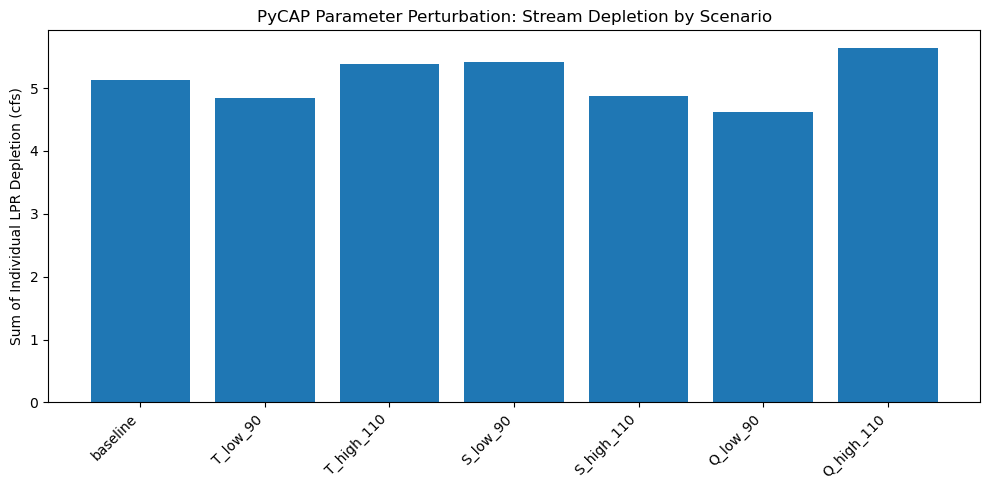

Saved: results/pycap_runs/parameter_perturbation/figures/sum_individual_depletion_by_scenario.png


In [17]:
plot_df = scenario_summary.copy()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["scenario"], plot_df["sum_individual_depletion_cfs"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Sum of Individual LPR Depletion (cfs)")
plt.title("PyCAP Parameter Perturbation: Stream Depletion by Scenario")
plt.tight_layout()

fig_path = FIGURES_DIR / "sum_individual_depletion_by_scenario.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Saved: {fig_path.relative_to(PROJECT_ROOT)}")


## 17. Plot: mean depletion potential by scenario

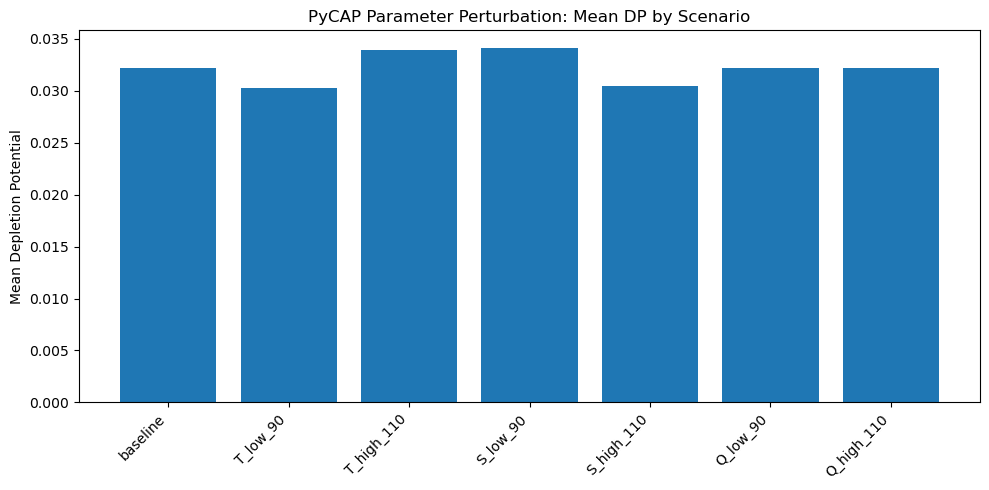

Saved: results/pycap_runs/parameter_perturbation/figures/mean_dp_by_scenario.png


In [18]:
plt.figure(figsize=(10, 5))
plt.bar(plot_df["scenario"], plot_df["dp_mean"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean Depletion Potential")
plt.title("PyCAP Parameter Perturbation: Mean DP by Scenario")
plt.tight_layout()

fig_path = FIGURES_DIR / "mean_dp_by_scenario.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Saved: {fig_path.relative_to(PROJECT_ROOT)}")


## 18. Plot: maximum depletion potential by scenario

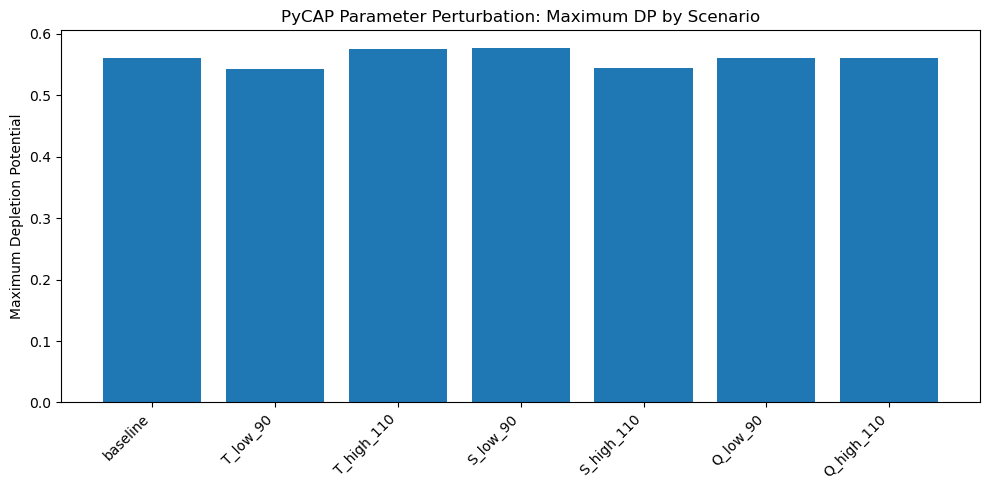

Saved: results/pycap_runs/parameter_perturbation/figures/max_dp_by_scenario.png


In [19]:
plt.figure(figsize=(10, 5))
plt.bar(plot_df["scenario"], plot_df["dp_max"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Maximum Depletion Potential")
plt.title("PyCAP Parameter Perturbation: Maximum DP by Scenario")
plt.tight_layout()

fig_path = FIGURES_DIR / "max_dp_by_scenario.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Saved: {fig_path.relative_to(PROJECT_ROOT)}")


## 19. Plot: scenario DP versus baseline DP

If points fall close to the 1:1 line, the scenario does not strongly change DP relative to baseline.


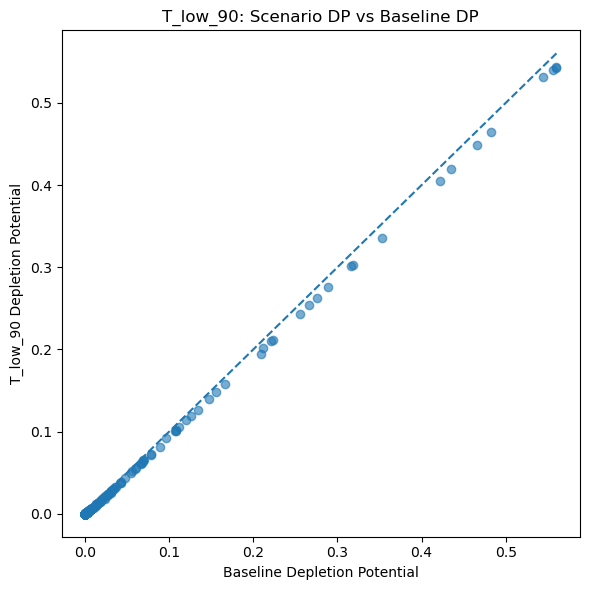

Saved: results/pycap_runs/parameter_perturbation/figures/T_low_90_dp_vs_baseline_dp.png


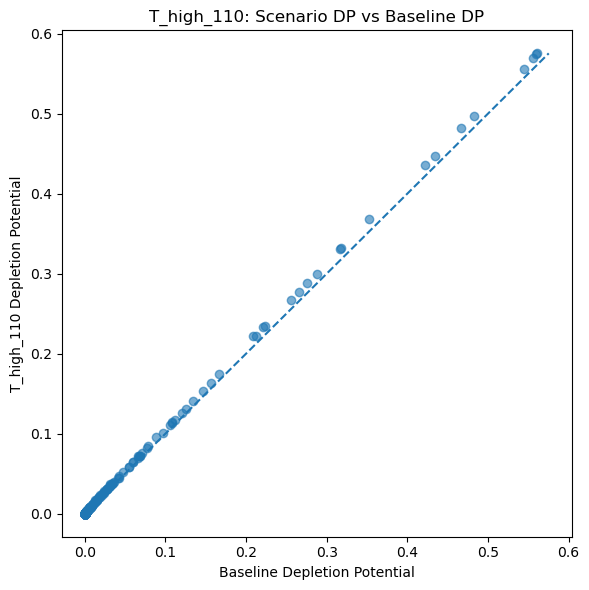

Saved: results/pycap_runs/parameter_perturbation/figures/T_high_110_dp_vs_baseline_dp.png


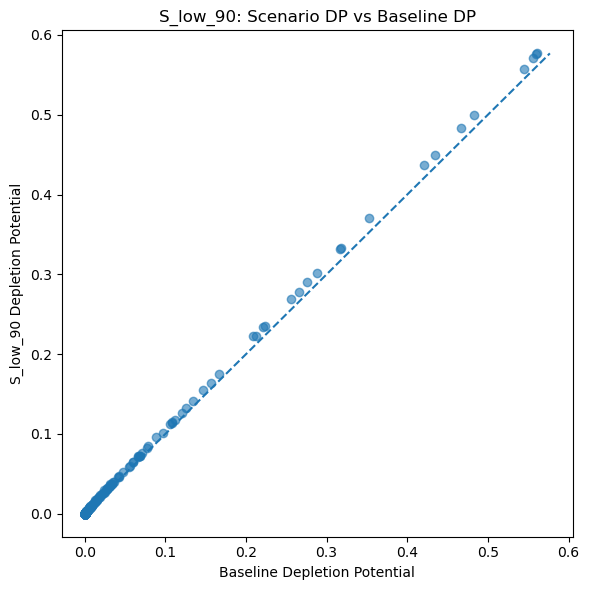

Saved: results/pycap_runs/parameter_perturbation/figures/S_low_90_dp_vs_baseline_dp.png


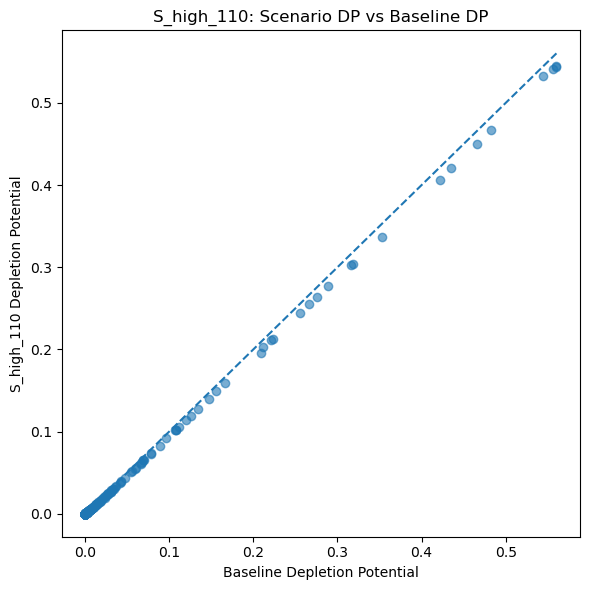

Saved: results/pycap_runs/parameter_perturbation/figures/S_high_110_dp_vs_baseline_dp.png


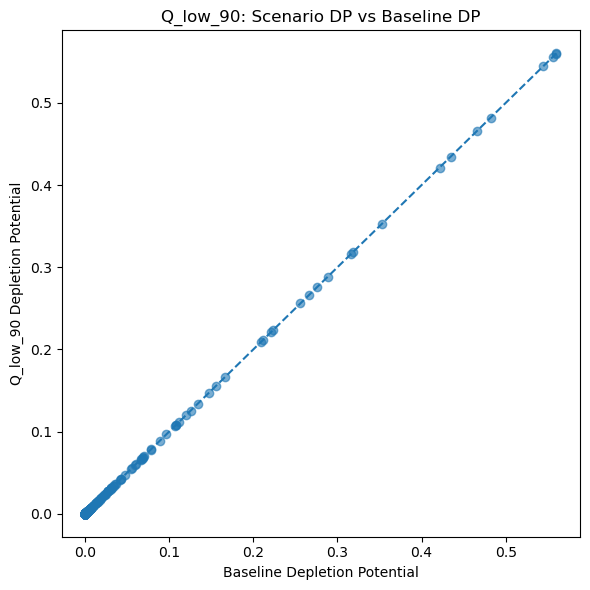

Saved: results/pycap_runs/parameter_perturbation/figures/Q_low_90_dp_vs_baseline_dp.png


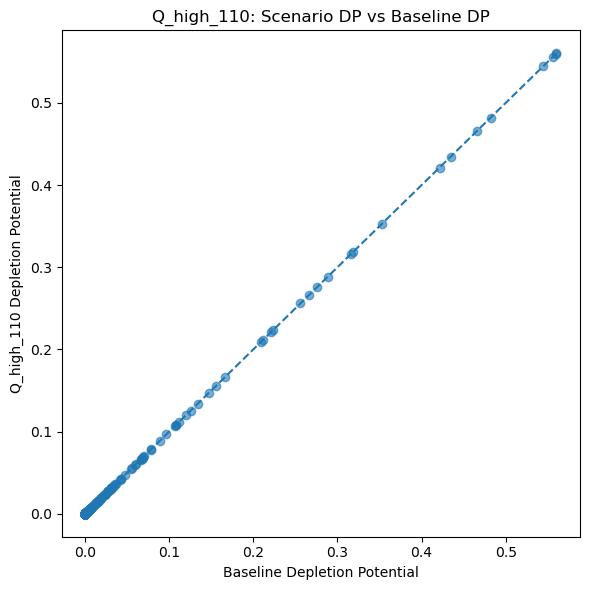

Saved: results/pycap_runs/parameter_perturbation/figures/Q_high_110_dp_vs_baseline_dp.png


In [20]:
for scenario in scenario_specs_df["scenario"]:
    if scenario == "baseline":
        continue

    group = all_comparisons[all_comparisons["scenario"] == scenario].copy()
    group = group.dropna(subset=["baseline_DP", "scenario_DP"])

    plt.figure(figsize=(6, 6))
    plt.scatter(group["baseline_DP"], group["scenario_DP"], alpha=0.6)

    max_value = max(group["baseline_DP"].max(), group["scenario_DP"].max())
    plt.plot([0, max_value], [0, max_value], linestyle="--")

    plt.xlabel("Baseline Depletion Potential")
    plt.ylabel(f"{scenario} Depletion Potential")
    plt.title(f"{scenario}: Scenario DP vs Baseline DP")
    plt.tight_layout()

    fig_path = FIGURES_DIR / f"{scenario}_dp_vs_baseline_dp.png"
    plt.savefig(fig_path, dpi=300)
    plt.show()

    print(f"Saved: {fig_path.relative_to(PROJECT_ROOT)}")


## 20. Plot: DP change distribution for each perturbation

This helps show whether the perturbation mostly shifts all wells slightly or strongly affects only a few wells.


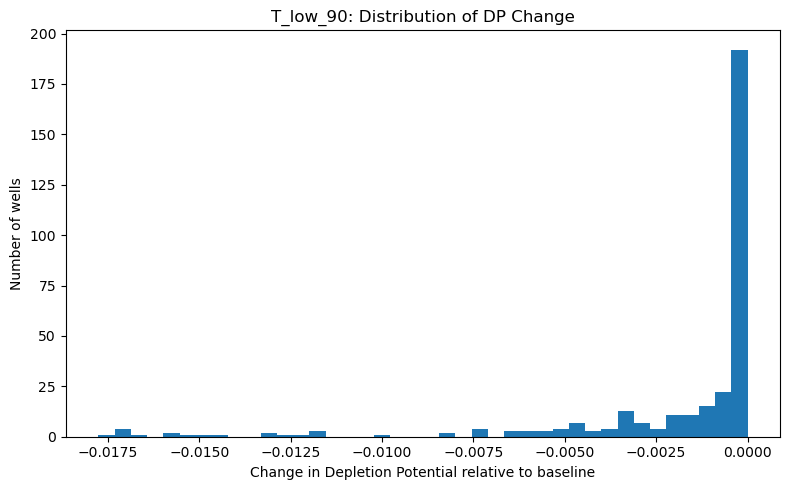

Saved: results/pycap_runs/parameter_perturbation/figures/T_low_90_delta_dp_histogram.png


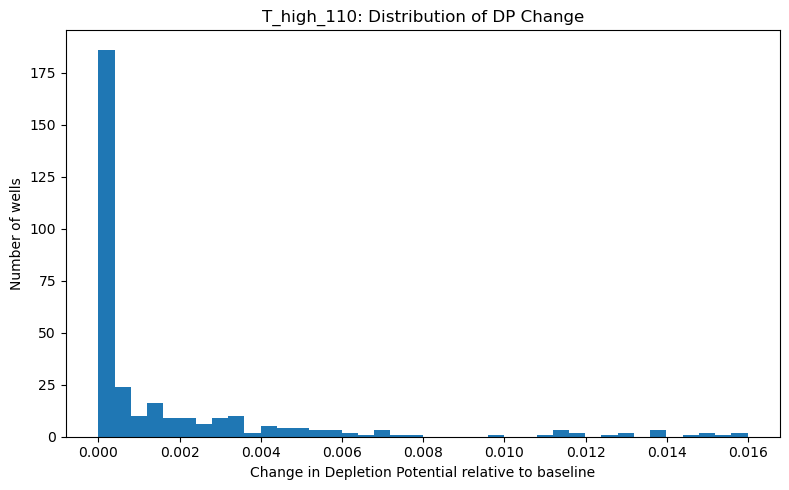

Saved: results/pycap_runs/parameter_perturbation/figures/T_high_110_delta_dp_histogram.png


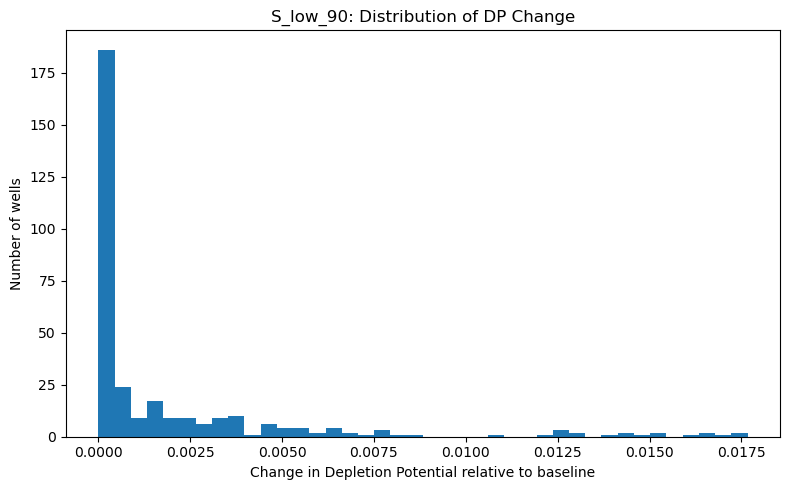

Saved: results/pycap_runs/parameter_perturbation/figures/S_low_90_delta_dp_histogram.png


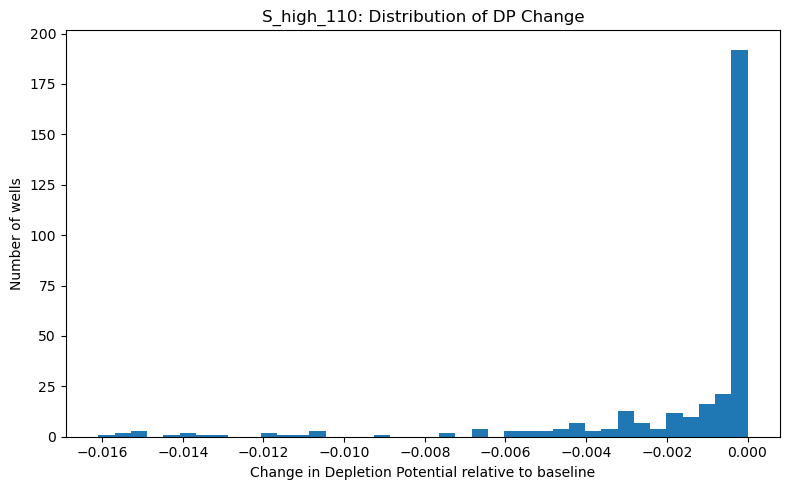

Saved: results/pycap_runs/parameter_perturbation/figures/S_high_110_delta_dp_histogram.png


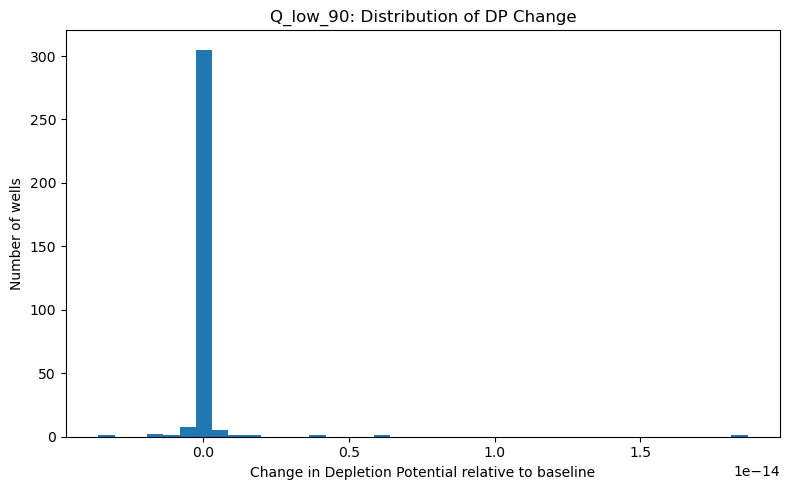

Saved: results/pycap_runs/parameter_perturbation/figures/Q_low_90_delta_dp_histogram.png


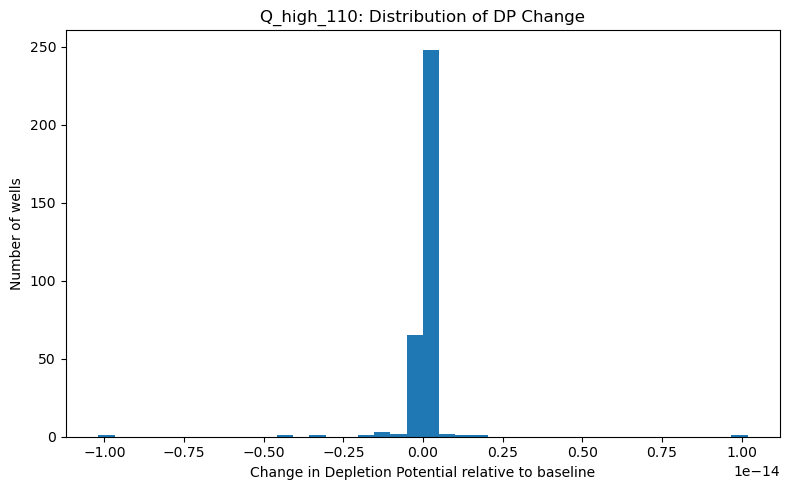

Saved: results/pycap_runs/parameter_perturbation/figures/Q_high_110_delta_dp_histogram.png


In [21]:
for scenario in scenario_specs_df["scenario"]:
    if scenario == "baseline":
        continue

    group = all_comparisons[all_comparisons["scenario"] == scenario].copy()
    delta_values = group["delta_DP"].replace([np.inf, -np.inf], np.nan).dropna()

    plt.figure(figsize=(8, 5))
    plt.hist(delta_values, bins=40)
    plt.xlabel("Change in Depletion Potential relative to baseline")
    plt.ylabel("Number of wells")
    plt.title(f"{scenario}: Distribution of DP Change")
    plt.tight_layout()

    fig_path = FIGURES_DIR / f"{scenario}_delta_dp_histogram.png"
    plt.savefig(fig_path, dpi=300)
    plt.show()

    print(f"Saved: {fig_path.relative_to(PROJECT_ROOT)}")


## 21. Create a short interpretation table

This table gives a first-pass interpretation of what changed.

You can edit these interpretation notes after reviewing the output.


In [22]:
interpretation_rows = []

for _, row in scenario_summary.iterrows():
    scenario = row["scenario"]

    if scenario == "baseline":
        note = "Reference case for comparison."
    elif row["parameter"] == "Q":
        note = (
            "Pumping perturbation. Stream depletion should scale with Q; "
            "depletion potential may change little if the model response is linear."
        )
    elif row["parameter"] == "T":
        note = (
            "Transmissivity perturbation. Changes how quickly and strongly pumping effects "
            "propagate through the aquifer to the stream."
        )
    elif row["parameter"] == "S":
        note = (
            "Storage perturbation. Most relevant to timing of transient depletion over the "
            "specified depletion horizon."
        )
    else:
        note = "Review scenario output."

    interpretation_rows.append(
        {
            "scenario": scenario,
            "parameter": row["parameter"],
            "factor": row["factor"],
            "sum_individual_depletion_cfs": row["sum_individual_depletion_cfs"],
            "dp_mean": row["dp_mean"],
            "dp_max": row["dp_max"],
            "wells_dp_ge_0_20": row["wells_dp_ge_0_20"],
            "interpretation_note": note,
        }
    )

interpretation_table = pd.DataFrame(interpretation_rows)

interpretation_path = TABLES_DIR / "first_pass_interpretation_table.csv"
interpretation_table.to_csv(interpretation_path, index=False)

print(f"Saved: {interpretation_path.relative_to(PROJECT_ROOT)}")
interpretation_table


Saved: results/pycap_runs/parameter_perturbation/tables/first_pass_interpretation_table.csv


,scenario,parameter,factor,sum_individual_depletion_cfs,dp_mean,dp_max,wells_dp_ge_0_20,interpretation_note
0,baseline,none,1.0,5.123893,0.032152,0.560296,19,Reference case for comparison.
1,T_low_90,T,0.9,4.847761,0.030288,0.543414,18,Transmissivity perturbation. Changes how quick...
2,T_high_110,T,1.1,5.381813,0.033904,0.575333,19,Transmissivity perturbation. Changes how quick...
3,S_low_90,S,0.9,5.409462,0.034093,0.576894,19,Storage perturbation. Most relevant to timing ...
4,S_high_110,S,1.1,4.873719,0.030463,0.545063,18,Storage perturbation. Most relevant to timing ...
5,Q_low_90,Q,0.9,4.611504,0.032152,0.560296,19,Pumping perturbation. Stream depletion should ...
6,Q_high_110,Q,1.1,5.636282,0.032152,0.560296,19,Pumping perturbation. Stream depletion should ...


## 22. Save notebook run summary

This documents the perturbation experiment.


In [23]:
notebook_summary_rows = [
    {"item": "project_root", "value": str(PROJECT_ROOT)},
    {"item": "baseline_yaml", "value": str(PYCAP_YAML_PATH.relative_to(PROJECT_ROOT))},
    {"item": "perturbation_folder", "value": str(PERTURBATION_DIR.relative_to(PROJECT_ROOT))},
    {"item": "number_of_scenarios", "value": len(scenario_specs_df)},
    {"item": "number_of_wells", "value": len(baseline_wells_df)},
    {"item": "baseline_T", "value": baseline_config["project_properties"].get("T")},
    {"item": "baseline_S", "value": baseline_config["project_properties"].get("S")},
    {"item": "baseline_sum_individual_depletion_cfs", "value": scenario_summary.loc[scenario_summary["scenario"] == "baseline", "sum_individual_depletion_cfs"].iloc[0]},
    {"item": "baseline_mean_dp", "value": scenario_summary.loc[scenario_summary["scenario"] == "baseline", "dp_mean"].iloc[0]},
    {"item": "baseline_max_dp", "value": scenario_summary.loc[scenario_summary["scenario"] == "baseline", "dp_max"].iloc[0]},
    {"item": "baseline_wells_dp_ge_0_20", "value": scenario_summary.loc[scenario_summary["scenario"] == "baseline", "wells_dp_ge_0_20"].iloc[0]},
    {"item": "run_timestamp", "value": datetime.now().isoformat(timespec="seconds")},
]

notebook_summary = pd.DataFrame(notebook_summary_rows)

notebook_summary_path = TABLES_DIR / "parameter_perturbation_notebook_summary.csv"
notebook_summary.to_csv(notebook_summary_path, index=False)

print(f"Saved: {notebook_summary_path.relative_to(PROJECT_ROOT)}")
notebook_summary


Saved: results/pycap_runs/parameter_perturbation/tables/parameter_perturbation_notebook_summary.csv


,item,value
0,project_root,/workspaces/Modeling-Uncertainties
1,baseline_yaml,data/raw/lpr_pycap/pycap_base/LPR_Redux.yml
2,perturbation_folder,results/pycap_runs/parameter_perturbation
3,number_of_scenarios,7
4,number_of_wells,327
5,baseline_T,1700.0
6,baseline_S,0.12
7,baseline_sum_individual_depletion_cfs,5.123893
8,baseline_mean_dp,0.032152
9,baseline_max_dp,0.560296


## 23. Final interpretation

This notebook is your first real uncertainty/sensitivity workflow.

The most important things to look at are:

1. Does changing `T` or `S` change depletion potential?
2. Does changing `Q` change total depletion but leave DP nearly unchanged?
3. Does the number of wells above `DP = 0.20` change?
4. Do the top-ranked wells stay the same?
5. Which parameter causes the largest changes relative to baseline?

The next notebook can build on this in one of two directions:

```text
05_pycap_parameter_perturbation_selected_wells.ipynb
```

or

```text
05_pycap_monte_carlo_uncertainty.ipynb
```

A good next step is usually to focus on selected high-impact wells and make plots that clearly show how `T`, `S`, and `Q` affect depletion and DP.
